# Remove with K-mean

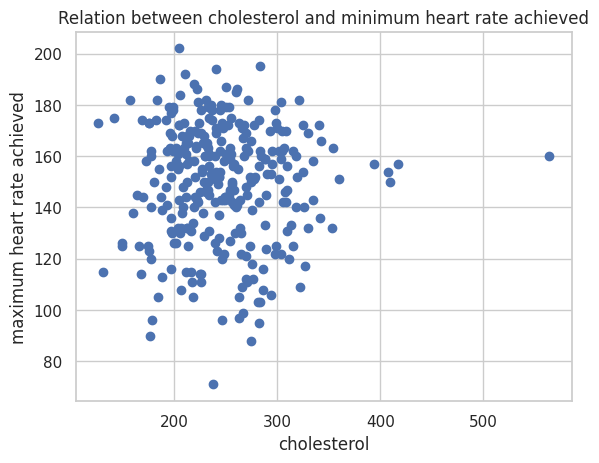

In [60]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sn

# Generating random data


data = pd.read_csv('heart.csv')
# data = data.dropna(subset=['Age', 'Fare'])
# Visualizing the random data
plt.scatter(data['chol'], data['thalachh'])
plt.title('Relation between cholesterol and minimum heart rate achieved')
plt.xlabel('cholesterol')
plt.ylabel('maximum heart rate achieved')
plt.show()



/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


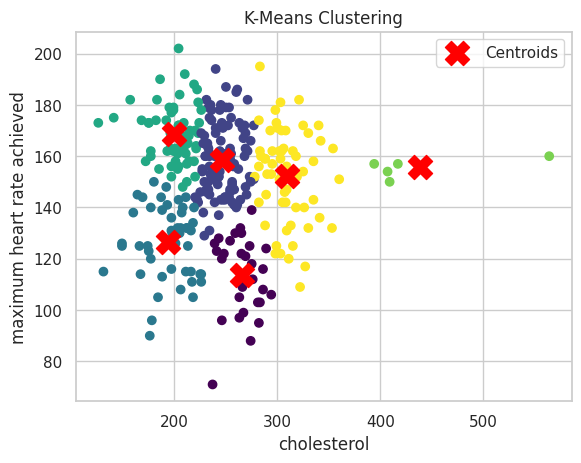

Inertia: 180572.0026489885


In [61]:
# Preprocessing data
X = data[['chol', 'thalachh']]

# Applying k-means clustering with k=3 (you can choose a different value for k)
kmeans = KMeans(n_clusters=6, random_state=42)
data['Cluster'] = kmeans.fit_predict(X)

# Visualizing the clusters
plt.scatter(data['chol'], data['thalachh'], c=data['Cluster'], cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('cholesterol')
plt.ylabel('maximum heart rate achieved')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.legend()
plt.show()

inertia = kmeans.inertia_

print("Inertia:", inertia)

In [62]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X, kmeans.labels_)

print("Before Silhouette score is: ", silhouette_avg)

Before Silhouette score is:  0.37085572552513946


In [63]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data_use = data[['chol', 'thalachh']]

df = pd.DataFrame(data_use)

# Specify the number of clusters (k)
k = 6

# Perform k-means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster_num'] = kmeans.fit_predict(df[['chol', 'thalachh']])

# Display the DataFrame with the new 'cluster_num' column
df





/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,chol,thalachh,cluster_num
0,233,150,1
1,250,187,1
2,204,172,3
3,236,178,1
4,354,163,5
...,...,...,...
298,241,123,0
299,264,132,0
300,193,141,2
301,131,115,2


In [64]:
import pandas as pd

# Create a new DataFrame with rows where cluster_num is 0
df_cluster_0,df_cluster_1,df_cluster_2,df_cluster_3,df_cluster_4,df_cluster_5 = df[df['cluster_num'] == 0],df[df['cluster_num'] == 1],df[df['cluster_num'] == 2],df[df['cluster_num'] == 3],df[df['cluster_num'] == 4],df[df['cluster_num'] == 5]

# Print the new DataFrame
print("Rows with cluster_num=0:")
print(df_cluster_0)
print("Rows with cluster_num=4:")
print(df_cluster_4)


Rows with cluster_num=0:
     chol  thalachh  cluster_num
11    275       139            0
60    265       130            0
84    265       122            0
89    248       122            0
129   269       121            0
139   263       105            0
165   286       108            0
179   276       112            0
184   243       128            0
187   266       109            0
198   267        99            0
202   270       111            0
216   263        97            0
218   254       127            0
224   239       126            0
226   281       103            0
231   289       124            0
233   246        96            0
240   269       112            0
243   274        88            0
247   246       120            0
252   294       106            0
254   273       125            0
256   259       130            0
262   282        95            0
268   286       116            0
269   283       103            0
272   237        71            0
274   275       11

In [65]:
import pandas as pd
import numpy as np

def calculate_euclidean_distance(df):
    # Calculate the average 'chol' and 'thalachh' values
    avg_chol = df['chol'].mean()
    avg_thalachh = df['thalachh'].mean()

    # Calculate Euclidean distance from the averages
    euclidean_distances = np.sqrt((df['chol'] - avg_chol)**2 + (df['thalachh'] - avg_thalachh)**2)

    # Add the Euclidean distances to the DataFrame
    df['euclidean_dist'] = euclidean_distances

    return df

# Calculate Euclidean distance for cluster_num
df_cluster_0_d = calculate_euclidean_distance(df_cluster_0)
df_cluster_1_d = calculate_euclidean_distance(df_cluster_1)
df_cluster_2_d = calculate_euclidean_distance(df_cluster_2)
df_cluster_3_d = calculate_euclidean_distance(df_cluster_3)
df_cluster_4_d = calculate_euclidean_distance(df_cluster_4)
df_cluster_5_d = calculate_euclidean_distance(df_cluster_5)
# Print the DataFrame with Euclidean distances
print(df_cluster_4_d)


     chol  thalachh  cluster_num  euclidean_dist
28    417       157            4       21.246176
85    564       160            4      125.876924
96    394       157            4       44.222166
220   407       154            4       31.240999
246   409       150            4       29.732137


<ipython-input-65-061e5d012d66>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['euclidean_dist'] = euclidean_distances
<ipython-input-65-061e5d012d66>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['euclidean_dist'] = euclidean_distances
<ipython-input-65-061e5d012d66>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [66]:
list_centroid = []

def remove_outliers_iqr(df):
    # Calculate the lower and upper bounds for outlier removal
    Q1 = df['euclidean_dist'].quantile(0.25)
    Q3 = df['euclidean_dist'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Remove outliers based on the euclidean_dist column
    df_no_outliers = df[(df['euclidean_dist'] >= lower_bound) & (df['euclidean_dist'] <= upper_bound)]

    avg_chol = df_no_outliers['chol'].mean()
    avg_thalachh = df_no_outliers['thalachh'].mean()

    list_centroid.append([avg_chol,avg_thalachh])
    return df_no_outliers
df_cluster_0_d = remove_outliers_iqr(df_cluster_0_d)
df_cluster_1_d = remove_outliers_iqr(df_cluster_1_d)
df_cluster_2_d = remove_outliers_iqr(df_cluster_2_d)
df_cluster_3_d = remove_outliers_iqr(df_cluster_3_d)
df_cluster_4_d = remove_outliers_iqr(df_cluster_4_d)
df_cluster_5_d = remove_outliers_iqr(df_cluster_5_d)

In [67]:
df_cluster_4_d

,chol,thalachh,cluster_num,euclidean_dist
28,417,157,4,21.246176
96,394,157,4,44.222166
220,407,154,4,31.240999
246,409,150,4,29.732137


In [68]:

dfs_cleaned = [df_cluster_0_d, df_cluster_1_d, df_cluster_2_d, df_cluster_3_d, df_cluster_4_d, df_cluster_5_d]
df_cleaned = pd.concat(dfs_cleaned, ignore_index=True)

# Print the cleaned DataFrame
print(df_cleaned)

     chol  thalachh  cluster_num  euclidean_dist
0     275       139            0       27.035453
1     265       130            0       16.550399
2     265       122            0        8.582403
3     248       122            0       19.971259
4     269       121            0        8.069031
..    ...       ...          ...             ...
293   319       152            5        9.771903
294   315       125            5       28.022665
295   311       120            5       32.471608
296   335       143            5       27.432171
297   318       140            5       15.203097

[298 rows x 4 columns]


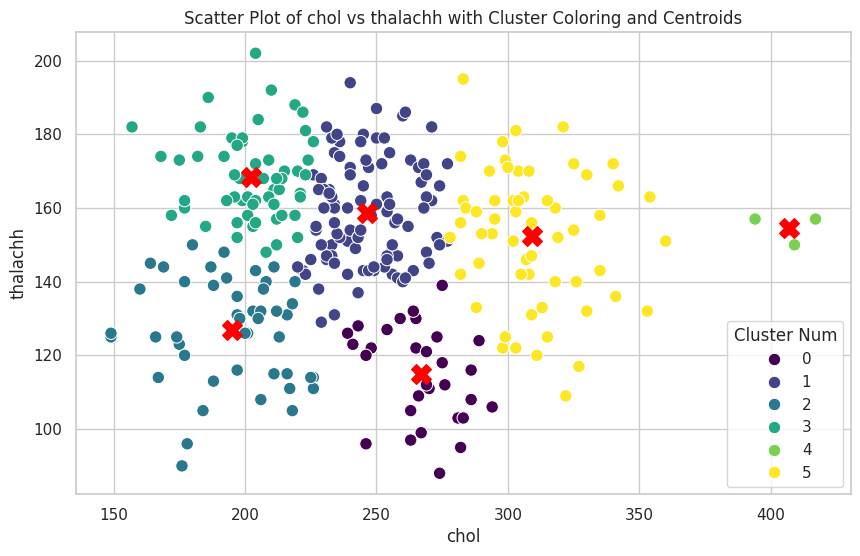

Inertia: 142434.26313481235


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [69]:
import seaborn as sns

# Set the style for better visualization
sns.set(style='whitegrid')

# Scatter plot with color-coded clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='chol', y='thalachh', hue='cluster_num', data=df_cleaned, palette='viridis', s=80)

# Add X marks for centroid positions
for i, centroid in enumerate(list_centroid):
    plt.scatter(centroid[0], centroid[1], marker='X', s=200, c='red')

# Customize the plot
plt.title('Scatter Plot of chol vs thalachh with Cluster Coloring and Centroids')
plt.xlabel('chol')
plt.ylabel('thalachh')
plt.legend(title='Cluster Num', loc='lower right')

# Show the plot
plt.show()

# Perform KMeans clustering and calculate inertia
features = df_cleaned[['chol', 'thalachh']]
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(features)
inertia = kmeans.inertia_
print("Inertia:", inertia)


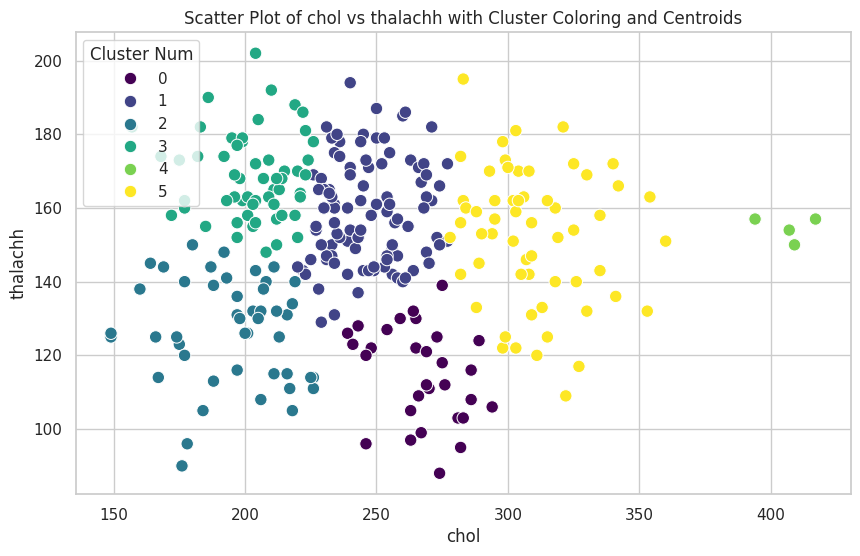

------------------------
Inertia: 142434.26313481235
------------------------
Before Silhouette score is:  0.36604551930628226


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [70]:
# Assuming list_centroid is the list of centroid values
# list_centroid = [[267.03333333333336, 114.9], [246.51, 158.54], [194.93617021276594, 126.85106382978724],
#                  [202.1206896551724, 168.5344827586207], [406.75, 154.5], [309.23728813559325, 152.42372881355934]]

# Set the style for better visualization
sns.set(style='whitegrid')

# Scatter plot with color-coded clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='chol', y='thalachh', hue='cluster_num', data=df_cleaned, palette='viridis', s=80)


# Customize the plot
plt.title('Scatter Plot of chol vs thalachh with Cluster Coloring and Centroids')
plt.xlabel('chol')
plt.ylabel('thalachh')
plt.legend(title='Cluster Num', loc='upper left')

# Show the plot
plt.show()

# Perform KMeans clustering and calculate inertia
features = df_cleaned[['chol', 'thalachh']]
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(features)
inertia = kmeans.inertia_
print("------------------------")
print("Inertia:", inertia)
print("------------------------")
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(features, kmeans.labels_)

print("Before Silhouette score is: ", silhouette_avg)

# Compare method

In [71]:
import pandas as pd

data2 = pd.read_csv('heart.csv')
dataset_select = data2[['chol', 'thalachh']]
def calculate_outliers(d):
    numerical_columns = data2.select_dtypes(exclude=['object']).columns

    for column in numerical_columns:
        series = d[column]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        lower_outliers = series[series < lower_bound]
        upper_outliers = series[series > upper_bound]

        total_lower_outliers = len(lower_outliers)
        total_upper_outliers = len(upper_outliers)
        total_outliers = total_lower_outliers + total_upper_outliers

        print(f"Column -> {column}: Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}, "
              f"Q1-1.5IQR: {lower_bound:.2f}, Q3+1.5IQR: {upper_bound:.2f}, "
              f"Total upper outliers: {total_upper_outliers}, "
              f"Total lower outliers: {total_lower_outliers}, "
              f"Total outliers: {total_outliers}")

# calculate_outliers(dataset_select)
print(dataset_select)

     chol  thalachh
0     233       150
1     250       187
2     204       172
3     236       178
4     354       163
..    ...       ...
298   241       123
299   264       132
300   193       141
301   131       115
302   236       174

[303 rows x 2 columns]


In [72]:
def remove_outliers(dataset, numerical_columns):
    dataset_cleaned = dataset.copy()

    # Iterate through numerical columns
    for column in numerical_columns:
        Q1 = dataset_cleaned[column].quantile(0.25)
        Q3 = dataset_cleaned[column].quantile(0.75)

        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = (dataset_cleaned[column] < lower_bound) | (dataset_cleaned[column] > upper_bound)

        dataset_cleaned = dataset_cleaned[~outliers]

    return dataset_cleaned

dataset_no_outliers = remove_outliers(dataset_select, ['chol', 'thalachh'])

In [73]:
dataset_no_outliers

,chol,thalachh
0,233,150
1,250,187
2,204,172
3,236,178
4,354,163
...,...,...
298,241,123
299,264,132
300,193,141
301,131,115
